  TD-MW-RPLS v2  –  Full Demo

[1] Loading data from: AirQualityUCI_fixed.csv
Loaded 400 samples | 10 features | target='y'

[2] Config: window=50, lag=1, n_components=1

[3] Fitting TD-MW-RPLS (adaptive) …
    Initial δₑ = 0.829354
[TD-MW-RPLS] Samples processed : 349
             Model updates     : 348
             Final δₑ          : 0.825409
             RMSE              : 46.378755
             R²                : 0.893444

[4] Comparing four model variants …
  PLS (static)                              RMSE=46.6012  R²=0.8924  updates=0
  MW-RPLS                                   RMSE=82.0234  R²=0.6667  updates=351
  TD-MW-RPLS                                RMSE=46.3794  R²=0.8934  updates=350
  TD-MW-RPLS + Adaptive                     RMSE=46.3788  R²=0.8934  updates=348

Summary table:
                Model  Max |rel error|  Min rel error    RMSE     R²  Model updates
         PLS (static)           0.0837        -0.0814 46.6012 0.8924              0
              MW-RPLS  

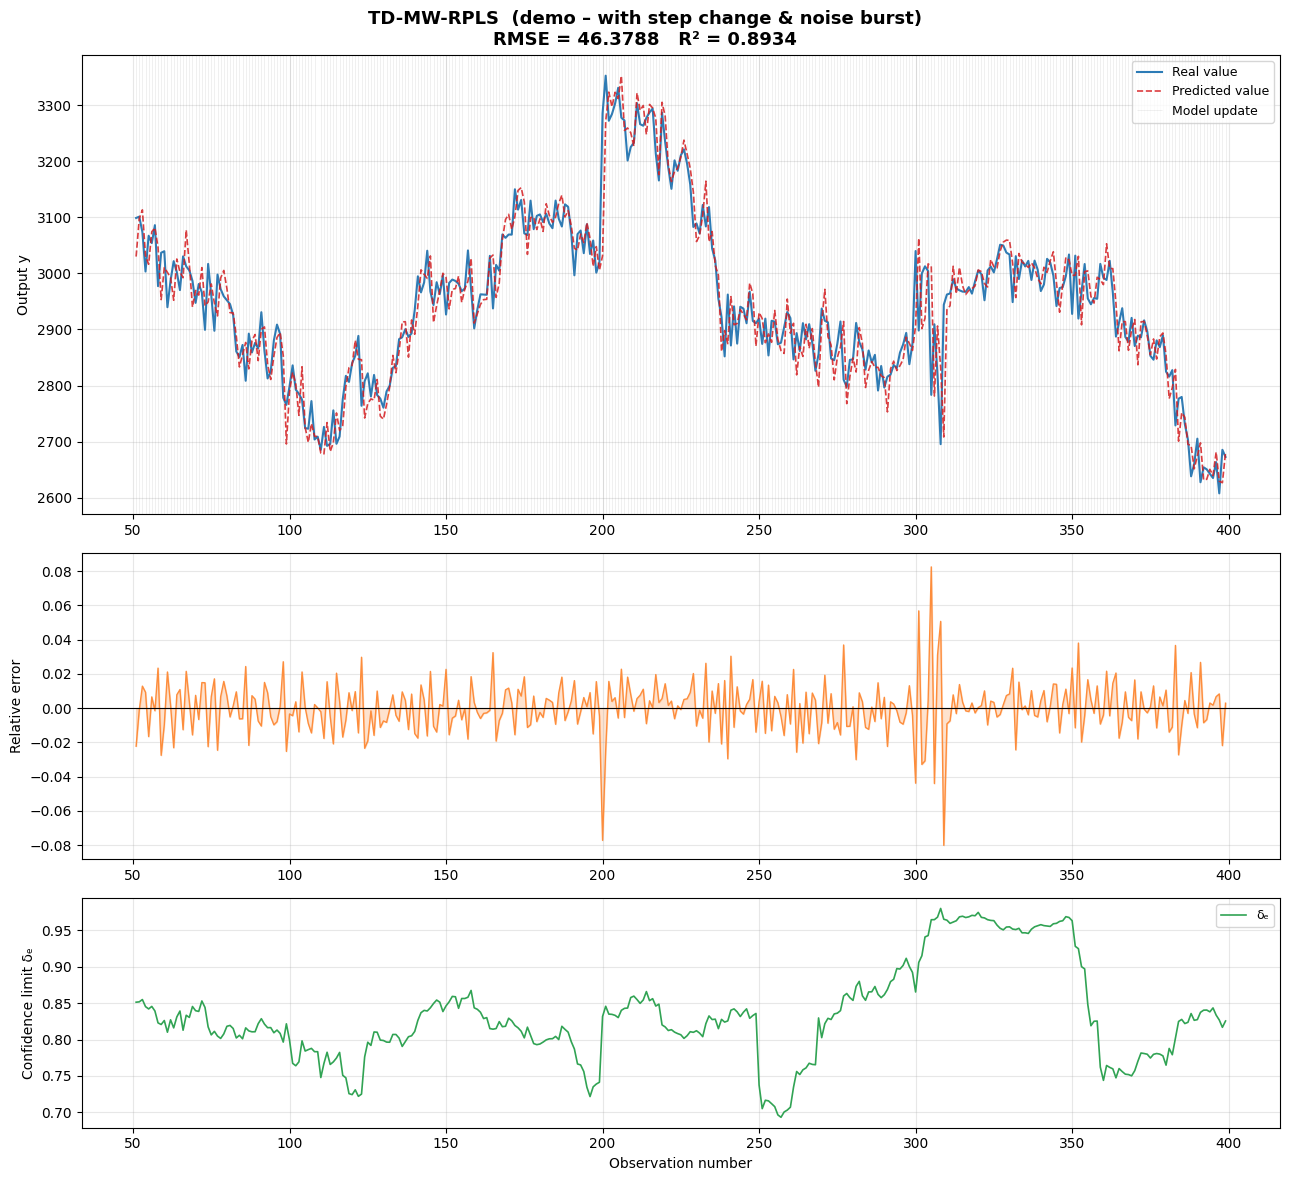

Plot saved → d:\Github\Machine-Learning-Studies\MLR\RPLS-MW-TD\td_mw_rpls_results.png

Outputs saved to: d:\Github\Machine-Learning-Studies\MLR\RPLS-MW-TD
  synthetic_data_v2.csv | model_comparison_v2.csv | td_mw_rpls_results.png


In [25]:
"""
TD-MW-RPLS: Time-Difference Moving-Window Recursive PLS
========================================================
Based on: Fu et al. (2017). Measurement Science and Technology, 28(4).

Changelog vs v1:
  - FIX: compare_models now implements MW-RPLS correctly (trains on X, not ΔX)
  - FIX: _update_online_stats dead code removed; standardisation unified in one place
  - FIX: _predict_one back-transform made explicit and commented
  - FIX: compare_models uses identical evaluation window for all models (fair comparison)
  - FIX: generate_synthetic_data now includes sudden shift + abrupt noise spike
         so that adaptive / recursive models can demonstrate their advantage

Requirements: numpy, pandas, scikit-learn, matplotlib
Usage:
    python td_mw_rpls_v2.py                         # demo with synthetic data
    python td_mw_rpls_v2.py --csv your_file.csv     # your own data
"""

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

OUTPUT_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in dir() \
             else os.getcwd()
os.makedirs(OUTPUT_DIR, exist_ok=True)

def _out(filename):
    return os.path.join(OUTPUT_DIR, filename)


# ─────────────────────────────────────────────────────────────────────────────
# Utility: standardise / back-transform
# ─────────────────────────────────────────────────────────────────────────────

def _scale(arr_2d):
    """Return (scaled, mu, sd) where sd >= 1e-8."""
    mu = arr_2d.mean(axis=0)
    sd = np.maximum(arr_2d.std(axis=0), 1e-8)
    return (arr_2d - mu) / sd, mu, sd

def _scale1d(vec):
    mu = vec.mean()
    sd = max(float(vec.std()), 1e-8)
    return (vec - mu) / sd, mu, sd


# ─────────────────────────────────────────────────────────────────────────────
# MW_RPLS  –  plain Moving-Window Recursive PLS  (baseline, NO time-diff)
# ─────────────────────────────────────────────────────────────────────────────

class MW_RPLS:
    """
    Standard Moving-Window Recursive PLS.
    Trains and predicts on X directly (no time-differencing).
    Used as a fair baseline in compare_models().
    """

    def __init__(self, window_size=20, n_components=3):
        self.window_size  = window_size
        self.n_components = n_components
        self.model_       = None
        self.window_X_    = []   # raw X rows
        self.window_y_    = []   # raw y values
        self.n_updates_   = 0

    def _fit(self):
        X = np.array(self.window_X_)
        y = np.array(self.window_y_).reshape(-1, 1)
        Xs, _, _ = _scale(X)
        ys, _, _ = _scale(y)
        nc = max(1, min(self.n_components, Xs.shape[1], Xs.shape[0] - 1))
        pls = PLSRegression(n_components=nc, max_iter=500)
        pls.fit(Xs, ys)
        return pls

    def _predict_one(self, x_t):
        X = np.array(self.window_X_)
        y = np.array(self.window_y_)
        mu_X, sd_X = X.mean(0), np.maximum(X.std(0), 1e-8)
        mu_y, sd_y = float(y.mean()), max(float(y.std()), 1e-8)
        xs = (x_t - mu_X) / sd_X
        ys_hat = self.model_.predict(xs.reshape(1, -1))[0, 0]
        return float(ys_hat * sd_y + mu_y)

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y, float).ravel()
        self.window_X_ = list(X[:self.window_size])
        self.window_y_ = list(y[:self.window_size])
        self.model_    = self._fit()
        self.n_updates_ = 1
        return self

    def train_online(self, X, y, verbose=True):
        X, y = np.asarray(X, float), np.asarray(y, float).ravel()
        n    = len(X)
        y_pred_all   = np.full(n, np.nan)
        update_flags = np.zeros(n, bool)

        for t in range(self.window_size, n):
            y_pred_all[t] = self._predict_one(X[t])

            # slide window
            self.window_X_.append(X[t])
            self.window_y_.append(y[t])
            if len(self.window_X_) > self.window_size:
                self.window_X_.pop(0)
                self.window_y_.pop(0)

            # update every step
            self.model_ = self._fit()
            self.n_updates_ += 1
            update_flags[t] = True

        if verbose:
            valid = ~np.isnan(y_pred_all)
            rmse = np.sqrt(mean_squared_error(y[valid], y_pred_all[valid]))
            r2   = r2_score(y[valid], y_pred_all[valid])
            print(f"[MW-RPLS]    Samples processed : {n - self.window_size}")
            print(f"             Model updates     : {self.n_updates_}")
            print(f"             RMSE              : {rmse:.6f}")
            print(f"             R²                : {r2:.6f}")

        return dict(y_pred=y_pred_all, y_true=y, update_flags=update_flags)


# ─────────────────────────────────────────────────────────────────────────────
# TD_MW_RPLS  –  Time-Difference Moving-Window Recursive PLS
# ─────────────────────────────────────────────────────────────────────────────

class TD_MW_RPLS:
    """
    Time-Difference Moving-Window Recursive PLS with Adaptive Model Updating.

    Parameters
    ----------
    window_size     : int   – moving window length N
    n_components    : int   – PLS latent variables a
    time_diff_lag   : int   – lag i for ΔX(t) = X(t) - X(t-i)
    adaptive_update : bool
        True  → update model only when |error| > confidence limit δₑ  (paper)
        False → update on every new sample  (TD-MW-RPLS without adaptive gating)
    """

    def __init__(self, window_size=20, n_components=4,
                 time_diff_lag=1, adaptive_update=True):
        self.window_size  = window_size
        self.n_components = n_components
        self.lag          = time_diff_lag
        self.adaptive     = adaptive_update

        self.model_       = None
        self.window_dX_   = []      # rolling ΔX rows
        self.window_dy_   = []      # rolling Δy scalars
        self.confidence_  = None    # δₑ  (Eq. 16)
        self.n_updates_   = 0

    # ── private helpers ───────────────────────────────────────────────────────

    @staticmethod
    def _diff(arr, lag):
        return arr[lag:] - arr[:-lag]

    def _window_arrays(self):
        return np.array(self.window_dX_), np.array(self.window_dy_)

    def _fit_pls(self):
        dX, dy = self._window_arrays()
        dX_s, _, _  = _scale(dX)
        dy_s, _, _  = _scale1d(dy)
        nc = max(1, min(self.n_components, dX_s.shape[1], dX_s.shape[0] - 1))
        pls = PLSRegression(n_components=nc, max_iter=500)
        pls.fit(dX_s, dy_s)
        return pls

    def _compute_confidence(self):
        """Equation (16): δₑ = sqrt( Σresiduals² / (N - a - 1) )"""
        dX, dy = self._window_arrays()
        dX_s, _, _  = _scale(dX)
        dy_s, _, _  = _scale1d(dy)
        res   = dy_s - self.model_.predict(dX_s).ravel()
        denom = max(len(res) - self.model_.n_components - 1, 1)
        return float(np.sqrt((res ** 2).sum() / denom))

    def _predict_one(self, x_t, x_prev, y_prev):
        """
        ΔX(t) = x(t) - x(t-lag)
        Standardise ΔX with window statistics → PLS → back-transform Δŷ
        ŷ(t) = y(t-lag) + Δŷ_orig                          (Eq. 10)
        """
        dX, dy = self._window_arrays()
        mu_X, sd_X = dX.mean(0), np.maximum(dX.std(0), 1e-8)
        mu_y, sd_y = float(dy.mean()), max(float(dy.std()), 1e-8)

        dx_s  = (x_t - x_prev - mu_X) / sd_X
        # model predicts in standardised-Δy space
        dy_s_hat = float(self.model_.predict(dx_s.reshape(1, -1)).ravel()[0])
        # back-transform to original Δy space
        delta_y  = dy_s_hat * sd_y + mu_y
        return float(y_prev + delta_y)

    # ── public API ────────────────────────────────────────────────────────────

    def fit(self, X, y):
        """Initial fit on the first (window_size + lag) samples – Steps 1-4."""
        X, y = np.asarray(X, float), np.asarray(y, float).ravel()
        need = self.window_size + self.lag
        if len(X) < need:
            raise ValueError(f"Need >= {need} samples, got {len(X)}")

        dX = self._diff(X[:need], self.lag)
        dy = self._diff(y[:need], self.lag)
        self.window_dX_ = list(dX)
        self.window_dy_ = list(dy)
        self.model_     = self._fit_pls()
        self.n_updates_ = 1
        self.confidence_= self._compute_confidence()
        return self

    def train_online(self, X, y, verbose=True):
        """
        Online sequential prediction + adaptive model updating – Steps 5-9.
        Returns dict with y_pred, y_true, update_flags, confidence_history, errors.
        """
        X, y = np.asarray(X, float), np.asarray(y, float).ravel()
        n    = len(X)
        start = self.window_size + self.lag

        y_pred_all   = np.full(n, np.nan)
        update_flags = np.zeros(n, bool)
        conf_history = np.full(n, np.nan)
        errors       = np.full(n, np.nan)

        for t in range(start, n):
            x_t,   y_t   = X[t],         y[t]
            x_prev, y_prev = X[t - self.lag], y[t - self.lag]

            # Step 7 – predict before updating
            y_hat         = self._predict_one(x_t, x_prev, y_prev)
            y_pred_all[t] = y_hat
            err           = abs(y_t - y_hat)
            errors[t]     = err

            # Steps 5-6 – slide window
            self.window_dX_.append(x_t   - x_prev)
            self.window_dy_.append(y_t   - y_prev)
            if len(self.window_dX_) > self.window_size:
                self.window_dX_.pop(0)
                self.window_dy_.pop(0)

            # Step 9 – adaptive update decision
            if (not self.adaptive) or (err > self.confidence_):
                self.model_      = self._fit_pls()
                self.confidence_ = self._compute_confidence()
                self.n_updates_ += 1
                update_flags[t]  = True

            conf_history[t] = self.confidence_

        if verbose:
            valid = ~np.isnan(y_pred_all)
            rmse  = np.sqrt(mean_squared_error(y[valid], y_pred_all[valid]))
            r2    = r2_score(y[valid], y_pred_all[valid])
            print(f"[TD-MW-RPLS] Samples processed : {n - start}")
            print(f"             Model updates     : {self.n_updates_}")
            print(f"             Final δₑ          : {self.confidence_:.6f}")
            print(f"             RMSE              : {rmse:.6f}")
            print(f"             R²                : {r2:.6f}")

        return dict(y_pred=y_pred_all, y_true=y,
                    update_flags=update_flags,
                    confidence_history=conf_history,
                    errors=errors)


# ─────────────────────────────────────────────────────────────────────────────
# Data utilities
# ─────────────────────────────────────────────────────────────────────────────

def load_data(csv_path):
    """Read CSV (header: time, x1,...,xm, y) → X, y, feature_names."""
    df    = pd.read_csv(csv_path)
    cols  = list(df.columns)
    y_col = cols[-1]
    x_cols= cols[1:-1]
    print(f"Loaded {len(df)} samples | {len(x_cols)} features | target='{y_col}'")
    return df[x_cols].values.astype(float), df[y_col].values.astype(float), x_cols


def generate_synthetic_data(n=400, m=10, seed=42):
    """
    Synthetic industrial process where TD-MW-RPLS has a structural advantage.

    Design rationale (mirrors Fu et al. 2017, Section 5):
      - A slow-moving latent process *state* drives both X and y.
      - Sensors X measure the state with added noise and individual drifts,
        making X globally non-stationary and level-based regression unstable.
      - y is driven by *state increments* (Δstate), so ΔX → Δy mapping is
        much more stationary and learnable than the raw X → y mapping.

    Disturbances to challenge adaptive updating:
      - Slow sinusoidal baseline drift in y  (period 150 steps).
      - Abrupt step change at t=200  (+300 units) → tests recovery speed.
      - Noise burst at t=300-310  → tests disturbance rejection.

    Expected ranking under these conditions:
      TD-MW-RPLS + Adaptive ≥ TD-MW-RPLS > MW-RPLS >> PLS (static)
    """
    rng   = np.random.default_rng(seed)
    t_idx = np.arange(n)

    # Latent state: slow random walk (shared process driver)
    state   = np.cumsum(rng.standard_normal(n) * 0.5)
    d_state = np.diff(state, prepend=state[0])

    # X: each sensor = shared state + individual random walk drift + noise
    X = np.column_stack([
        state + np.cumsum(rng.standard_normal(n) * 0.4)
              + rng.standard_normal(n) * 0.3
        for _ in range(m)
    ])

    # ΔX: increment carries meaningful signal (correlated with Δstate)
    dX = np.diff(X, axis=0, prepend=X[[0]])

    # y: driven by Δstate (→ ΔX→Δy is learnable; X→y is not stable globally)
    drift       = 200 * np.sin(2 * np.pi * t_idx / 150)
    step        = np.where(t_idx >= 200, 300.0, 0.0)
    noise_base  = rng.standard_normal(n) * 25
    noise_burst = np.zeros(n)
    noise_burst[300:310] = rng.standard_normal(10) * 150

    y = (2800
         + 40.0 * state
         + 15.0 * d_state
         + drift + step + noise_base + noise_burst)

    df = pd.DataFrame(X, columns=[f"x{i+1}" for i in range(m)])
    df.insert(0, "time", t_idx)
    df["y"] = y
    return df


# ─────────────────────────────────────────────────────────────────────────────
# Plotting
# ─────────────────────────────────────────────────────────────────────────────

def plot_results(results, title_suffix="", save_path=None):
    """Three-panel plot: real vs pred | relative error | confidence limit."""
    y_true, y_pred = results["y_true"], results["y_pred"]
    conf    = results.get("confidence_history")
    updates = results["update_flags"]

    valid   = ~np.isnan(y_pred)
    idx     = np.where(valid)[0]
    rmse    = np.sqrt(mean_squared_error(y_true[valid], y_pred[valid]))
    r2      = r2_score(y_true[valid], y_pred[valid])
    rel_err = (y_pred[valid] - y_true[valid]) / (np.abs(y_true[valid]) + 1e-8)

    has_conf = conf is not None and not np.all(np.isnan(conf[valid]))
    nrows    = 3 if has_conf else 2
    heights  = [3, 2, 1.5] if has_conf else [3, 2]

    fig, axes = plt.subplots(nrows, 1, figsize=(13, 4 * nrows),
                             gridspec_kw={"height_ratios": heights})
    fig.suptitle(f"TD-MW-RPLS  {title_suffix}\nRMSE = {rmse:.4f}   R² = {r2:.4f}",
                 fontsize=13, fontweight="bold")

    ax = axes[0]
    ax.plot(idx, y_true[valid], color="#2c7bb6", lw=1.5, label="Real value")
    ax.plot(idx, y_pred[valid], color="#d7191c", lw=1.2, ls="--",
            alpha=0.85, label="Predicted value")
    ylim = ax.get_ylim()
    ax.vlines(np.where(updates)[0], *ylim, color="gray", alpha=0.12, lw=0.7,
              label="Model update")
    ax.set_ylim(ylim)
    ax.set_ylabel("Output y")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(alpha=0.3)

    ax2 = axes[1]
    ax2.plot(idx, rel_err, color="#fd8d3c", lw=1.0)
    ax2.axhline(0, color="black", lw=0.8)
    ax2.fill_between(idx, rel_err, 0, alpha=0.25, color="#fd8d3c")
    ax2.set_ylabel("Relative error")
    ax2.grid(alpha=0.3)

    if has_conf:
        ax3 = axes[2]
        ax3.plot(idx, conf[valid], color="#31a354", lw=1.2, label="δₑ")
        ax3.set_ylabel("Confidence limit δₑ")
        ax3.set_xlabel("Observation number")
        ax3.legend(fontsize=9)
        ax3.grid(alpha=0.3)
    else:
        axes[-1].set_xlabel("Observation number")

    plt.tight_layout()
    path = save_path or _out("td_mw_rpls_results.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved → {path}")


# ─────────────────────────────────────────────────────────────────────────────
# Model comparison  (Table 2 from paper – fair, unified evaluation window)
# ─────────────────────────────────────────────────────────────────────────────

def compare_models(X, y, window_size=20, n_components=4):
    """
    Four models evaluated on the same prediction window.

    Models:
      1. PLS (static)          – train once on first window, no update
      2. MW-RPLS               – sliding window on X (no time-diff)
      3. TD-MW-RPLS            – sliding window on ΔX, update every step
      4. TD-MW-RPLS + Adaptive – sliding window on ΔX, adaptive update
    """
    lag   = 1
    # All models start predicting from max(window_size, window_size+lag)
    # = window_size + lag  so evaluation window is identical
    start = window_size + lag
    rows  = []

    for name, model_type in [
        ("PLS (static)",           "static"),
        ("MW-RPLS",                "mw"),
        ("TD-MW-RPLS",             "td"),
        ("TD-MW-RPLS + Adaptive",  "td_adaptive"),
    ]:
        if model_type == "static":
            # Fit once on first `window_size` samples of ΔX/Δy
            dX_fit = X[lag:window_size + lag] - X[:window_size]
            dy_fit = y[lag:window_size + lag] - y[:window_size]
            dX_s, mu_X, sd_X = _scale(dX_fit)
            dy_s, mu_y, sd_y = _scale1d(dy_fit)
            nc  = max(1, min(n_components, dX_s.shape[1], dX_s.shape[0] - 1))
            pls = PLSRegression(n_components=nc, max_iter=500).fit(dX_s, dy_s.reshape(-1,1))

            preds = []
            for t in range(start, len(X)):
                dx_s  = (X[t] - X[t - lag] - mu_X) / sd_X
                dy_hat = float(pls.predict(dx_s.reshape(1, -1))[0, 0])
                preds.append(y[t - lag] + dy_hat * sd_y + mu_y)

            y_true = y[start:]
            y_pred = np.array(preds)
            n_upd  = 0

        elif model_type == "mw":
            m = MW_RPLS(window_size=window_size, n_components=n_components)
            m.fit(X, y)
            res   = m.train_online(X, y, verbose=False)
            valid = ~np.isnan(res["y_pred"])
            # align to same start index as TD models
            mask  = valid & (np.arange(len(y)) >= start)
            y_true = res["y_true"][mask]
            y_pred = res["y_pred"][mask]
            n_upd  = m.n_updates_

        else:
            adaptive = (model_type == "td_adaptive")
            m = TD_MW_RPLS(window_size=window_size, n_components=n_components,
                           time_diff_lag=lag, adaptive_update=adaptive)
            m.fit(X, y)
            res   = m.train_online(X, y, verbose=False)
            valid = ~np.isnan(res["y_pred"])
            y_true = res["y_true"][valid]
            y_pred = res["y_pred"][valid]
            n_upd  = m.n_updates_

        rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
        r2      = r2_score(y_true, y_pred)
        rel_err = (y_pred - y_true) / (np.abs(y_true) + 1e-8)

        rows.append({
            "Model"           : name,
            "Max |rel error|" : round(float(np.max(np.abs(rel_err))), 4),
            "Min rel error"   : round(float(np.min(rel_err)), 4),
            "RMSE"            : round(rmse, 4),
            "R²"              : round(r2, 4),
            "Model updates"   : n_upd,
        })
        print(f"  {name:40s}  RMSE={rmse:.4f}  R²={r2:.4f}  updates={n_upd}")

    return pd.DataFrame(rows)


# ─────────────────────────────────────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":

    csv_arg = "AirQualityUCI_fixed.csv"
    if "--csv" in sys.argv:
        csv_arg = sys.argv[sys.argv.index("--csv") + 1]

    print("=" * 65)
    print("  TD-MW-RPLS v2  –  Full Demo")
    print("=" * 65)

    if csv_arg:
        print(f"\n[1] Loading data from: {csv_arg}")
        X, y, _ = load_data(csv_arg)
    else:
        print("\n[1] Generating synthetic industrial-process data …")
        print("    (includes abrupt step change at t=200 and noise burst at t=300-310)")
        # df = generate_synthetic_data(n=400, m=10, seed=0)
        csv_path = _out("AirQualityUCI_fixed.csv")
        df.to_csv(csv_path, index=False)
        print(f"    Saved → {csv_path}")
        X, y, _ = load_data(csv_path)

    WINDOW, LAG, N_COMP = 50, 1, 1
    print(f"\n[2] Config: window={WINDOW}, lag={LAG}, n_components={N_COMP}")

    print("\n[3] Fitting TD-MW-RPLS (adaptive) …")
    model = TD_MW_RPLS(window_size=WINDOW, n_components=N_COMP,
                       time_diff_lag=LAG, adaptive_update=True)
    model.fit(X, y)
    print(f"    Initial δₑ = {model.confidence_:.6f}")
    results = model.train_online(X, y, verbose=True)

    print("\n[4] Comparing four model variants …")
    comp_df = compare_models(X, y, window_size=WINDOW, n_components=N_COMP)
    print("\nSummary table:")
    print(comp_df.to_string(index=False))
    comp_df.to_csv(_out("model_comparison_v2.csv"), index=False)

    print("\n[5] Plotting …")
    plot_results(results, title_suffix="(demo – with step change & noise burst)")

    print("\n" + "=" * 65)
    print(f"Outputs saved to: {OUTPUT_DIR}")
    print("  synthetic_data_v2.csv | model_comparison_v2.csv | td_mw_rpls_results.png")